In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

In [2]:
os.getcwd()

'C:\\Users\\jrlin\\Seaglider'

In [3]:
# open the timeseries file
ds = xr.open_dataset('sg194_2025_04_17_Edmonds_timeseries.nc')
display(ds)

# check the first time to see if an offset is needed
ds.time.values[0]


<xarray.Dataset> Size: 351kB
Dimensions:                                   (gps_info: 33,
                                               sg_data_point: 1876, dive: 11,
                                               trajectory: 11)
Coordinates:
    ctd_time                                  (sg_data_point) datetime64[ns] 15kB ...
    ctd_depth                                 (sg_data_point) float32 8kB ...
    latitude                                  (sg_data_point) float32 8kB ...
    longitude                                 (sg_data_point) float32 8kB ...
  * trajectory                                (trajectory) int32 44B 3 4 ... 13
Dimensions without coordinates: gps_info, sg_data_point, dive
Data variables: (12/67)
    gps_info_dive_number                      (gps_info) int32 132B ...
    sg_data_point_dive_number                 (sg_data_point) int32 8kB ...
    log_gps_time                              (gps_info) datetime64[ns] 264B ...
    time                                      (sg_data_point) datetime64[ns] 15kB ...
    pressure                                  (sg_data_point) float32 8kB ...
    depth                                     (sg_data_point) float32 8kB ...
    ...                                        ...
    end_longitude                             (dive) float32 44B ...
    depth_avg_curr_east                       (dive) float32 44B ...
    depth_avg_curr_north                      (dive) float32 44B ...
    depth_avg_curr_qc                         (dive) |S1 11B ...
    latlong_qc                                (dive) |S1 11B ...
    glider                                    |S12 12B ...
Attributes: (12/47)
    project:                         2025 04 17 Edmonds
    title:                           Physical, chemical, and biological data ...
    summary:                         SG194 2025 04 17 Edmonds
    source:                          Seaglider SG194
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2026-04-20T18:04:20Z
    uuid:                            5ce68302-3ce9-11f1-9ea1-774cb83f18cf
    base_station_version:            3.0.6
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

np.datetime64('2026-04-17T16:06:00.790999808')

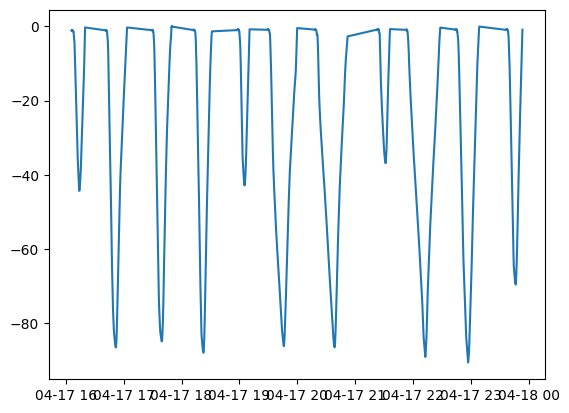

In [4]:
# check the depth to see if an offset is needed
ds.depth.values[0]
depth = ds.depth.values
time = ds.time.values
plt.plot(time, -depth)

# is depth above 0? is a linear or variable offset needed? if linear, add a value to all depth values

In [5]:
# SG Data Point Files

# make sure you are where you want to be
print(os.getcwd())

# rename variables for clarity
ds['PAR_470nm'] = ds['eng_wlbb2fl_sig470nm']
ds['particle_concentration_700nm'] = ds['eng_wlbb2fl_sig700nm']
ds['chlorophyll_695nm'] = ds['eng_wlbb2fl_sig695nm']
ds['dissolved_oxygen'] = ds['aanderaa4330_dissolved_oxygen']
ds['instrument_dissolved_oxygen'] = ds['aanderaa4330_instrument_dissolved_oxygen']

# add metadata
ds['PAR_470nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig470nm'
ds['particle_concentration_700nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig700nm'
ds['chlorophyll_695nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig695nm'
ds['dissolved_oxygen'].attrs['pre_cleaning_name'] = 'aanderaa4330_dissolved_oxygen'
ds['instrument_dissolved_oxygen'].attrs['pre_cleaning_name'] = 'aanderaa4330_instrument_dissolved_oxygen'

#Select the relevant variables (depth_corrected if correction applied, just depth if not)
new_ds = ds[['time', 'depth', 'latitude', 'longitude','temperature', 'salinity', 'dissolved_oxygen', 'instrument_dissolved_oxygen', 'PAR_470nm', 'particle_concentration_700nm', 'chlorophyll_695nm']]

#Convert to DataFrame and save as csv and nc 
new_ds.to_dataframe().reset_index().to_csv('cleaned_sg194_edmonds_test_timeseries.csv', index=False)
new_ds.to_netcdf('cleaned_sg194_edmonds_test_timeseries.nc')
display(new_ds)

C:\Users\jrlin\Seaglider


<xarray.Dataset> Size: 113kB
Dimensions:                       (sg_data_point: 1876)
Coordinates:
    latitude                      (sg_data_point) float32 8kB 47.83 ... 47.82
    longitude                     (sg_data_point) float32 8kB -122.4 ... -122.4
    ctd_time                      (sg_data_point) datetime64[ns] 15kB 2026-04...
    ctd_depth                     (sg_data_point) float32 8kB 0.5147 ... 0.8802
Dimensions without coordinates: sg_data_point
Data variables:
    time                          (sg_data_point) datetime64[ns] 15kB 2026-04...
    depth                         (sg_data_point) float32 8kB 1.108 ... 0.8883
    temperature                   (sg_data_point) float32 8kB 9.969 ... 10.09
    salinity                      (sg_data_point) float32 8kB nan nan ... nan
    dissolved_oxygen              (sg_data_point) float32 8kB nan nan ... nan
    instrument_dissolved_oxygen   (sg_data_point) float32 8kB nan nan ... nan
    PAR_470nm                     (sg_data_point) float32 8kB 572.0 ... 846.0
    particle_concentration_700nm  (sg_data_point) float32 8kB 135.0 ... 131.0
    chlorophyll_695nm             (sg_data_point) float32 8kB 532.0 ... 505.0
Attributes: (12/47)
    project:                         2025 04 17 Edmonds
    title:                           Physical, chemical, and biological data ...
    summary:                         SG194 2025 04 17 Edmonds
    source:                          Seaglider SG194
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2026-04-20T18:04:20Z
    uuid:                            5ce68302-3ce9-11f1-9ea1-774cb83f18cf
    base_station_version:            3.0.6
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

In [6]:
# Depth Average Currents Files

# rename variables for clarity
ds['U_DAC'] = ds['depth_avg_curr_east']
ds['V_DAC'] = ds['depth_avg_curr_north']

# add metadata
ds['U_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_east'
ds['V_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_north'

#Select the relevant variables
new_ds = ds[['U_DAC', 'V_DAC', 'start_time', 'end_time', 'start_latitude', 'end_latitude', 'start_longitude', 'end_longitude','dive_number']]
display(new_ds)

#Convert to DataFrame and save as csv and nc 
new_ds.to_dataframe().reset_index().to_csv('cleaned_DAC_sg194_edmonds_test_timeseries.csv', index=False)
new_ds.to_netcdf('cleaned_DAC_sg194_edmonds_test_timeseries.nc')


<xarray.Dataset> Size: 484B
Dimensions:          (dive: 11)
Dimensions without coordinates: dive
Data variables:
    U_DAC            (dive) float32 44B ...
    V_DAC            (dive) float32 44B ...
    start_time       (dive) datetime64[ns] 88B ...
    end_time         (dive) datetime64[ns] 88B ...
    start_latitude   (dive) float32 44B ...
    end_latitude     (dive) float32 44B ...
    start_longitude  (dive) float32 44B ...
    end_longitude    (dive) float32 44B ...
    dive_number      (dive) int32 44B ...
Attributes: (12/47)
    project:                         2025 04 17 Edmonds
    title:                           Physical, chemical, and biological data ...
    summary:                         SG194 2025 04 17 Edmonds
    source:                          Seaglider SG194
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2026-04-20T18:04:20Z
    uuid:                            5ce68302-3ce9-11f1-9ea1-774cb83f18cf
    base_station_version:            3.0.6
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6